In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Data set loaded successfully!")

Data set loaded successfully!


In [15]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [16]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
print("---------------- Missing value report ----------------")
missing_counts = df.isnull().sum()
print(missing_counts)
print("Total missing values:", sum(missing_counts))

---------------- Missing value report ----------------
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Total missing values: 0


In [18]:
duplicate_rows = df.duplicated()
print("---------------- Duplicate row report ----------------")
print(df[duplicate_rows])
print("Total duplicated rows:", sum(duplicate_rows))

---------------- Duplicate row report ----------------
Empty DataFrame
Columns: [customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []

[0 rows x 21 columns]
Total duplicated rows: 0


In [19]:
print("---------------- Target Column Analysis ----------------")
print(f"Datatype: {df['Churn'].dtype}")
print("")
print(f"Unique Values: {df['Churn'].unique()}")
print("")
print(f"Distribution Percentage:\n{df['Churn'].value_counts(normalize=True) * 100}")

---------------- Target Column Analysis ----------------
Datatype: object

Unique Values: ['No' 'Yes']

Distribution Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


---------------- Numerical Column Analysis ----------------
Numerical Columns are: 
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Description of Numerical Columns: 
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000



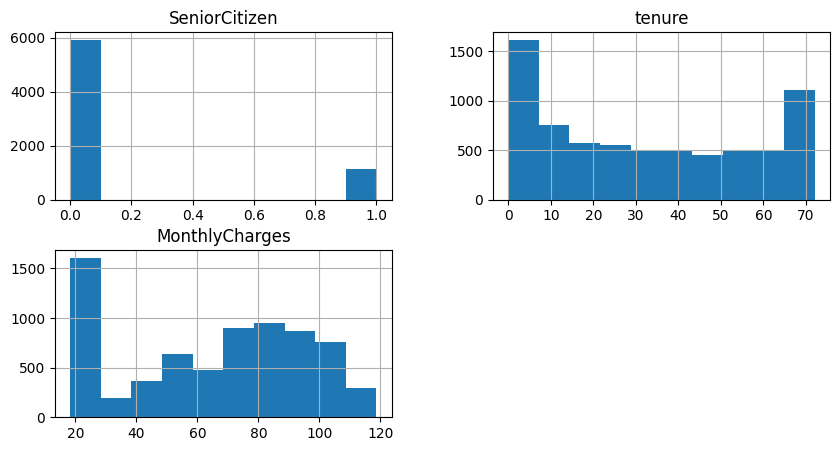

In [20]:
numcols=[]
catcols=[]
print("---------------- Numerical Column Analysis ----------------")
print("Numerical Columns are: ")
for cols in df.columns:
  if (df[cols].dtype == 'int64' or df[cols].dtype == 'float64'):
      numcols.append(cols)
  else:
    catcols.append(cols)
print(numcols)
print("")
print("Description of Numerical Columns: ")
print(df[numcols].describe())

print("")

df[numcols].hist(
    figsize=(10,5)
)

plt.show()


In [21]:
categorical_cols = df.select_dtypes(
    include="object"
).columns

for col in categorical_cols:

    print("\n",col)

    print(
        df[col].value_counts()
    )


 customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

 gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

 Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

 Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

 PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

 MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

 InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

 OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

 OnlineBackup
OnlineBackup
No                     3088
Yes                

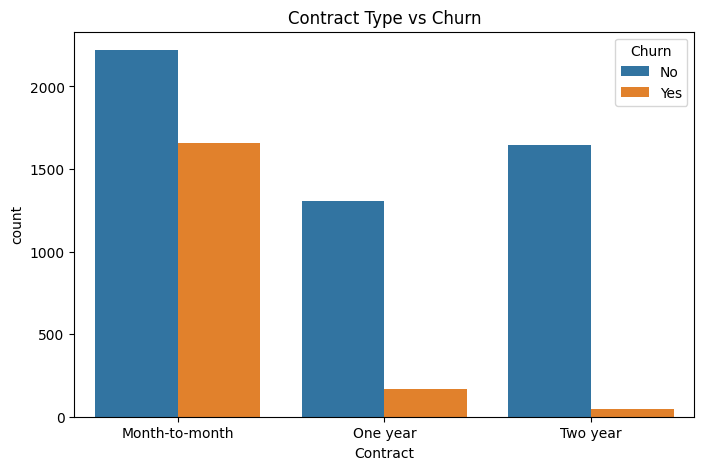

In [22]:
import seaborn as sns
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title(
    "Contract Type vs Churn"
)

plt.show()

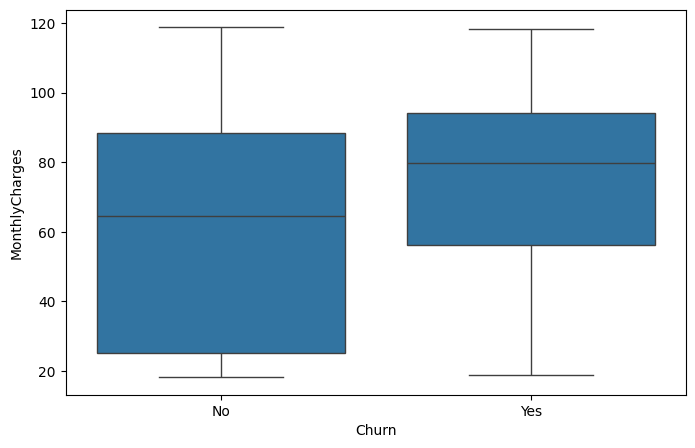

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.show()

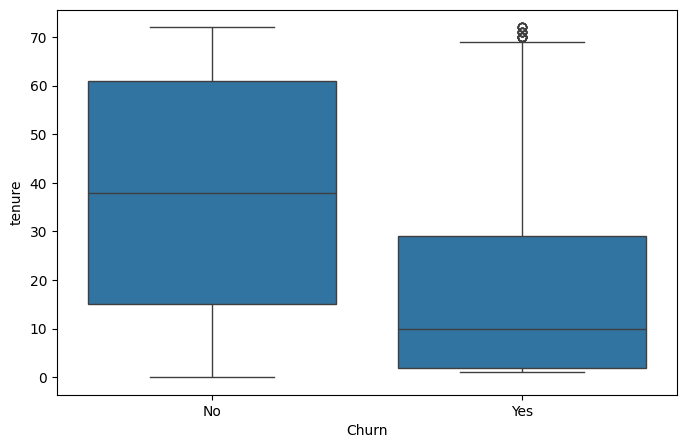

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.show()

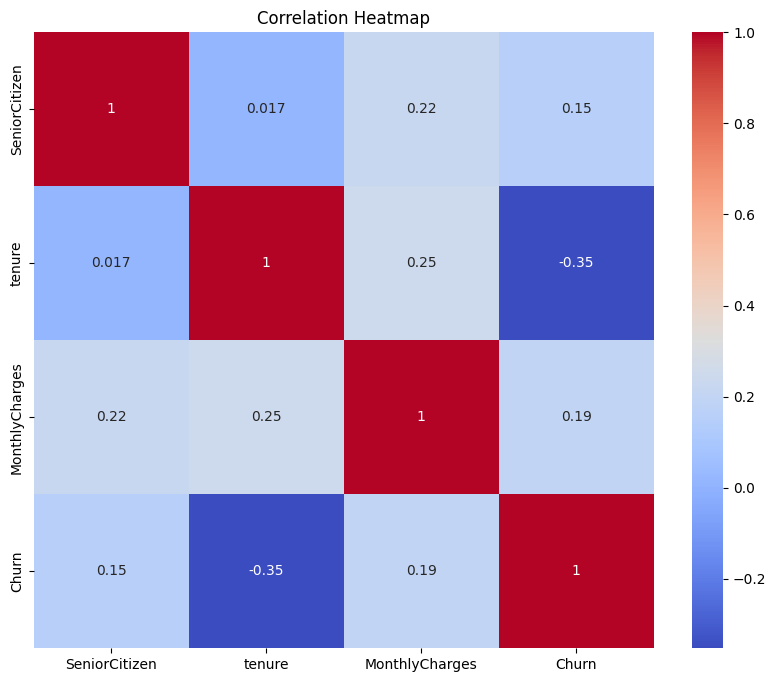

In [25]:
df_corr = df.copy()

df_corr["Churn"] = (
    df_corr["Churn"]=="Yes"
).astype(int)

corr = df_corr.select_dtypes(
    include=np.number
).corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

Business Insights

1. Customers with month-to-month contracts are more likely to churn.

2. Customers with higher monthly charges show higher churn risk.

3. Customers with longer tenure are less likely to churn.

4. Customers using electronic check payments show higher churn.

5. Contract type, tenure and monthly charges appear to be important churn indicators.